# Reads the connectflow mesh

This notebook explains:
1. How to read a CONNECTFLOW mesh in pydelling.
3. How to set the top boundaries in pydelling (land and sea).
4. How to convert th CONNECTFLOW into a PFOTRAN format.

For a better detail of the code, please refer to the Python script *read_connectflow_mesh.py*


In [1]:
# Import and set the path to pydelling
import sys
import os
os.getcwd()
sys.path.insert(0, "../../.")

In [2]:
# Import the modules to read the CONNECTFLOW mesh
import pyvista as pv
from pydelling.readers.ConnectFlowMeshReader import ConnectFlowMeshReader
path_cf_mesh = "dummy_cf_2cell_mesh"
reader = ConnectFlowMeshReader(path_cf_mesh + ".msh")

[17:55:09] INFO     -----------------------------------

           INFO     Welcome to Pydelling 1.13.24

           INFO     -----------------------------------

Reading elements: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 1822.82it/s]


We can write a CONNECTFLOW mesh into a .vtk format

[17:55:11] INFO     Converting mesh to vtk and exporting to dummy_cf_2cell_mesh.vtk

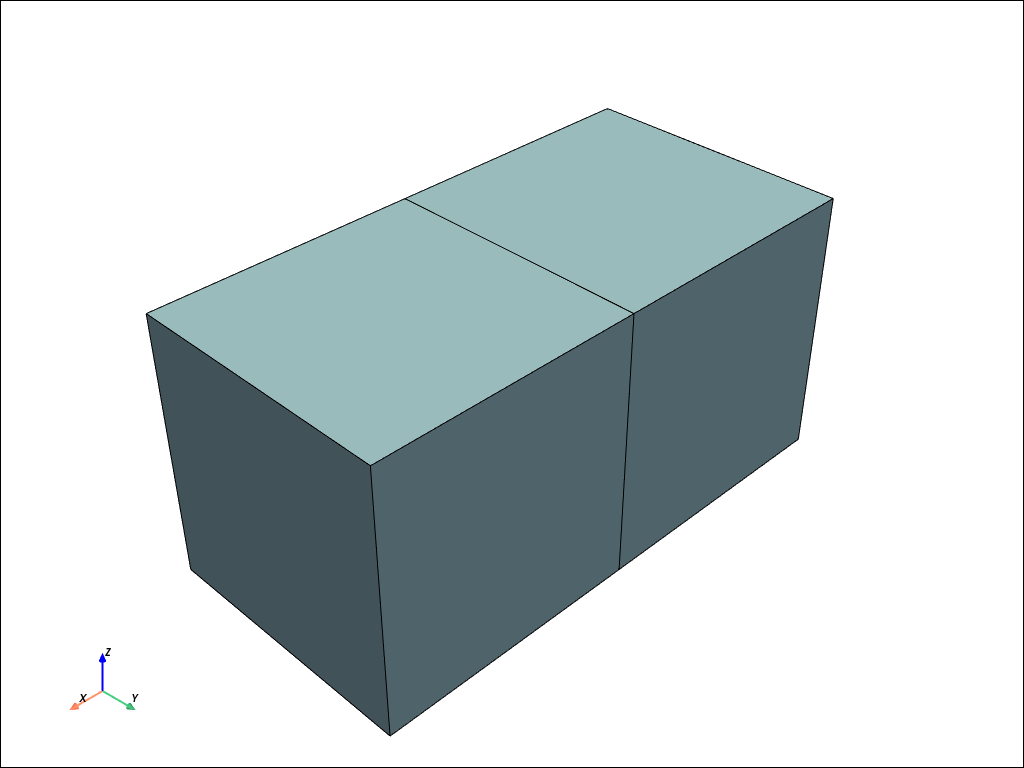

In [3]:
# We can convert the CONNECTFLOW mesh into a .vtk format -> generates dummy_cf_2cell_mesh.vtk
reader.to_vtk(path_cf_mesh + ".vtk")
grid = pv.read(path_cf_mesh + ".vtk")
grid.plot(show_scalar_bar=False, show_axes=True, notebook=True, border=True, show_edges=True)

In [4]:
# We can set the two top regions: land (z>z_ref) and sea (z<z_ref)
reader.find_mesh_connections()
reader.find_boundary_elements()
z_ref = 0.25
reader.set_topography_boundaries(z_coord=z_ref)
print(reader.boundaries)

           INFO     Finding mesh connections

Finding connections: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 10990.32it/s]


           INFO     Finding boundary elements

Assigning topography boundaries.: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<?, ?it/s]

{'land': {0: quadrilateral-5, 1: quadrilateral-11}, 'sea': {}}


3. To convert the CONNECTFLOW mesh into PFLOTRAN unstructured explicit mesh, we use the class method implicit_to_explicit

In [5]:
reader.implicit_to_explicit(project_name="cf2pflotran")

           INFO     Finding implicit mesh connectivities

           INFO     Writing mesh file to output

           INFO     Writing mesh to hdf5 (output\cf2pflotran-domain.h5)

It generates a directory with
1. the mesh *igp_mesh.msh*
2. the material file *1.mat*
3. 3and the top regions *land.ex* and *sea.ex*